In [14]:
import coderdata as cd
import os
import numpy as np
import pandas as pd
from umap import UMAP
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator  # Correct import for new RDKit
import pubchempy as pcp

In [15]:
import coderdata_processing
import importlib
importlib.reload(coderdata_processing)
from coderdata_processing import min_max_scaling, filter_biomarkers, filter_feature, data_attribute_check, preprocess_experiment_with_footprint, cat_drug_response_features, unify_feature_across_dataset, get_total_mutation_types, summarize_datasets, summarize_df_matrices, min_max_scaling_across_dfs, dip_data_across_dfs, get_cell_id_across_dfs, cat_drug_response_features_across_datasets, dip_experiments_across_dfs, visualize_responses_across_datasets, summarize_all_available_metrics

In [16]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [17]:
# datasets = ["beataml", "bladder", "ccle", "colorectal", "cptac", "ctrpv2", "fimm", "gcsi", "gdscv1", "gdscv2", "hcmi", "liver", "mpnst", "nci60", "novartis", "pancreatic", "prism", "sarcoma"]
# ignore dataset "cptac", "hcmi", "novartis", "sarcoma" due to response metric issues
datasets = ["beataml", "bladder", "ccle", "colorectal", "ctrpv2", "fimm", "gcsi", "gdscv1", "gdscv2", "liver", "mpnst", "nci60", "pancreatic", "prism"]
# avail_metrics = ["fit_auc", "fit_ic50", "fit_ec50", "fit_r2", "fit_ec50se", "fit_einf", "fit_hs", "aac", "auc", "dss"]


# bad datasets: ctrpv2, fimm, gdscv1, gdscv2, liver, mpnst, nci60, prism
# good datasets: ccle, gcsi, 
# datasets = ["prism"]
data_path = '../data/Cancer/coderdata/'
for data_name in datasets:
    cd.download(name=data_name, local_path=data_path)

loaded_datasets = {}
for data_name in datasets:
    print(f"Loading dataset: {data_name}")
    loaded_datasets[data_name] = cd.load(name=data_name, local_path=data_path)

Downloaded 'https://api.figshare.com/v2/file/download/57224264' to '../data/Cancer/coderdata/genes.csv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224267' to '../data/Cancer/coderdata/beataml_drugs.tsv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224348' to '../data/Cancer/coderdata/beataml_experiments.tsv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224435' to '../data/Cancer/coderdata/beataml_drug_descriptors.tsv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224456' to '../data/Cancer/coderdata/beataml_transcriptomics.csv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224459' to '../data/Cancer/coderdata/beataml_proteomics.csv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57224462' to '../data/Cancer/coderdata/beataml_mutations.csv.gz'
Downloaded 'https://api.figshare.com/v2/file/download/57349832' to '../data/Cancer/coderdata/beataml_samples.csv'
Downloaded 'https://api.figshare.com/v2/file/download

Exception: Failed to get dataset details from Figshare: <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>


In [ ]:
avail_metrics = summarize_all_available_metrics(loaded_datasets)
avail_metrics

Available metrics in dataset 'beataml': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'bladder': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'ccle': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'colorectal': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'ctrpv2': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'fimm': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'gcsi': ['fit_auc' 'fit_ic50' 'fit_ec50' 'fit_r2' 'fit_ec50se' 'fit_einf' 'fit_hs'
 'aac' 'auc' 'dss']
Available metrics in dataset 'gdscv1': ['fit_auc' 'fit_ic50' '

['fit_ic50',
 'dss',
 'fit_r2',
 'fit_hs',
 'fit_ec50se',
 'auc',
 'aac',
 'fit_auc',
 'fit_ec50',
 'fit_einf']

Dataset: beataml
📊 Summary statistics for `fit_ic50`:

count    23544.000000
mean         5.447146
std          2.223728
min         -4.125240
5%           0.496610
25%          4.913000
50%          5.657000
75%          6.528000
95%          7.655850
max         13.207100



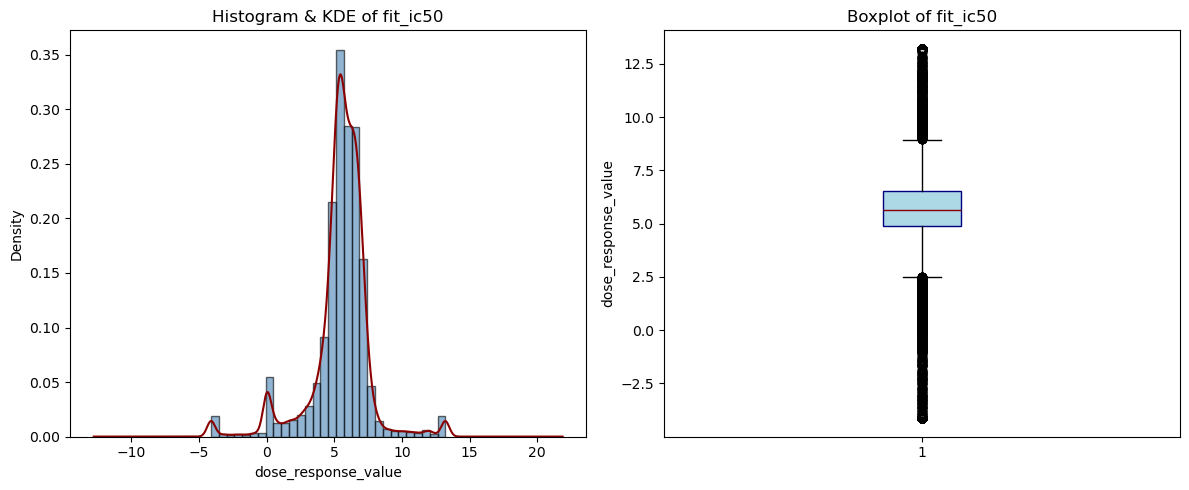

Dataset: bladder
📊 Summary statistics for `fit_ic50`:

count    2663.000000
mean        5.671758
std         1.692654
min        -1.009000
5%          3.131000
25%         4.840000
50%         5.766000
75%         6.716000
95%         8.175000
max         8.928000



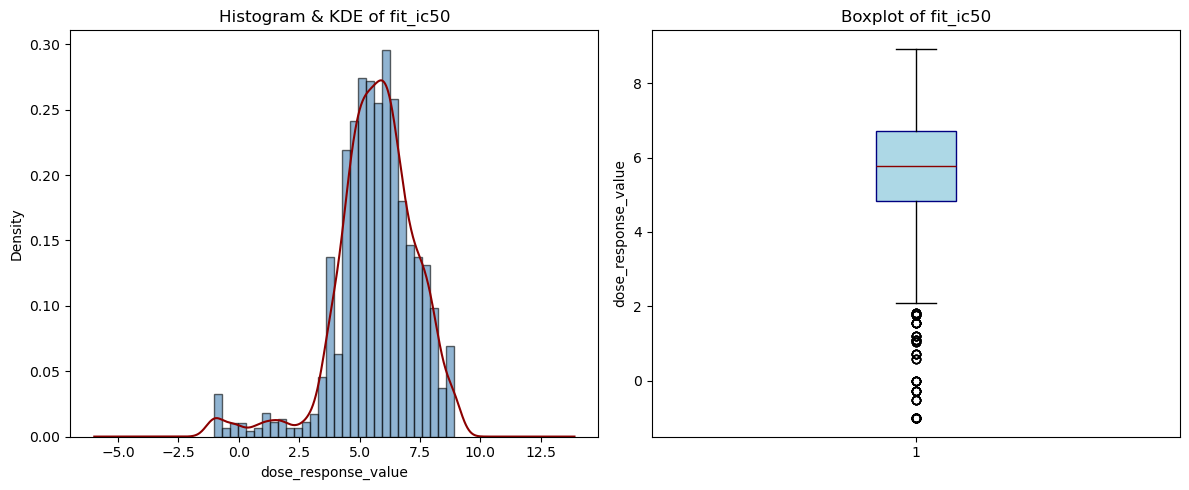

Dataset: ccle
📊 Summary statistics for `fit_ic50`:

count    8488.000000
mean        5.410738
std         1.980087
min        -1.639210
5%          0.859345
25%         4.932000
50%         5.329000
75%         6.391000
95%         8.138200
max        11.661300



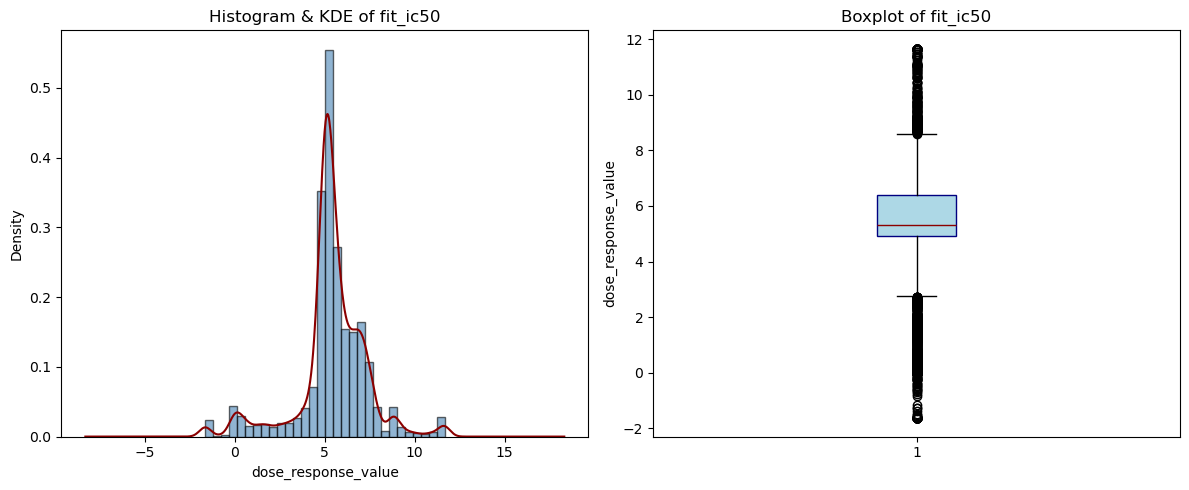

Dataset: colorectal
📊 Summary statistics for `fit_ic50`:

count    140.000000
mean       1.176409
std        1.726824
min        0.002529
5%         0.013790
25%        0.516350
50%        0.927250
75%        1.241750
95%        1.773950
max       12.000000



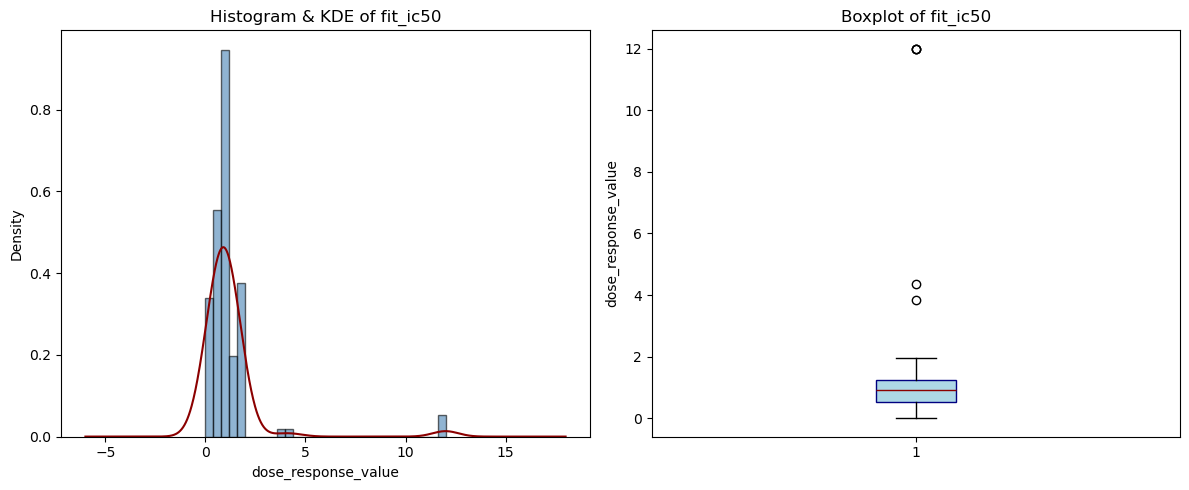

Dataset: ctrpv2
📊 Summary statistics for `fit_ic50`:

count    211288.000000
mean          4.803627
std           1.655406
min          -1.962520
5%            1.837350
25%           4.185000
50%           4.809000
75%           5.549000
95%           7.426000
max           9.169000



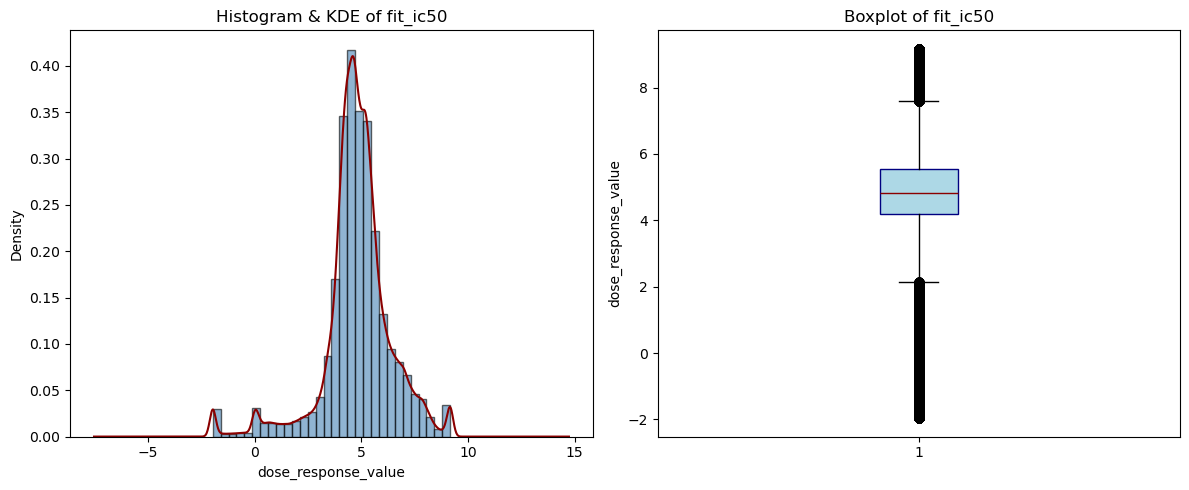

Dataset: fimm
📊 Summary statistics for `fit_ic50`:

count    1833.000000
mean        5.878953
std         2.022727
min        -2.116640
5%          2.372600
25%         4.936000
50%         5.858000
75%         6.992000
95%         8.626200
max        12.000000



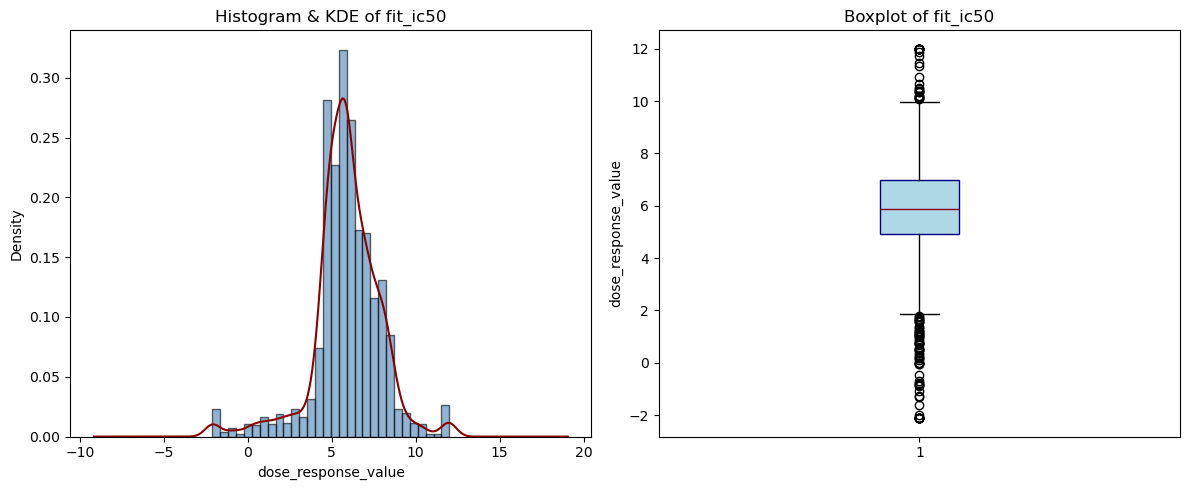

Dataset: gcsi
📊 Summary statistics for `fit_ic50`:

count    9311.000000
mean        5.760843
std         1.708302
min        -0.316440
5%          2.558500
25%         4.876000
50%         5.814000
75%         7.039000
95%         8.065500
max         8.606800



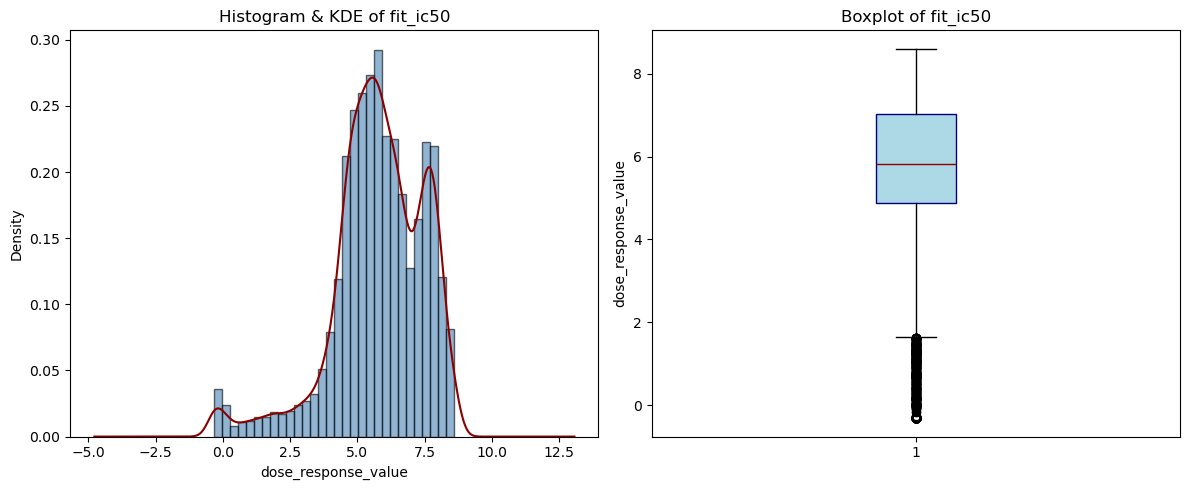

Dataset: gdscv1
📊 Summary statistics for `fit_ic50`:

count    154540.000000
mean          5.224776
std           2.089668
min          -2.022270
5%            1.138000
25%           4.580000
50%           5.280000
75%           6.189000
95%           8.236000
max          11.980000



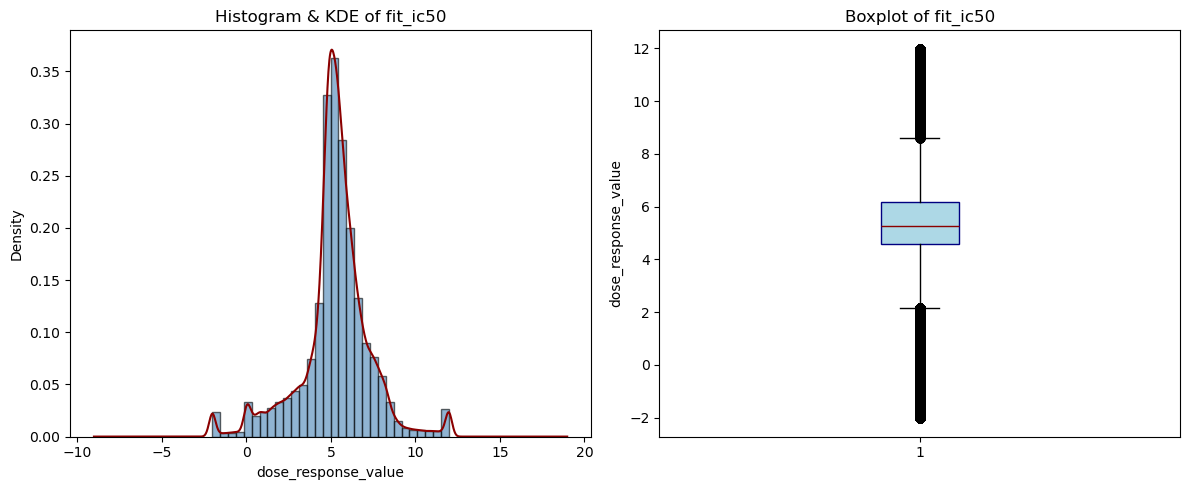

Dataset: gdscv2
📊 Summary statistics for `fit_ic50`:

count    66425.000000
mean         5.145634
std          2.632136
min         -5.282520
5%           0.384980
25%          4.344000
50%          5.231000
75%          6.300000
95%          8.616800
max         13.140000



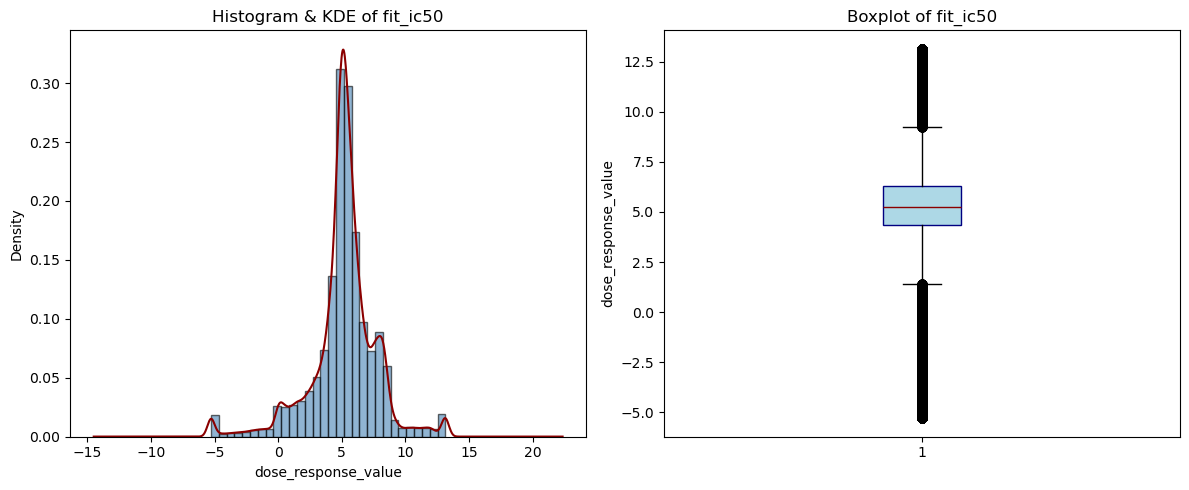

Dataset: liver
📊 Summary statistics for `fit_ic50`:

count    3609.000000
mean        5.333933
std         2.684776
min        -7.040000
5%          0.588220
25%         4.748000
50%         5.459000
75%         6.248000
95%         7.945600
max        17.437200



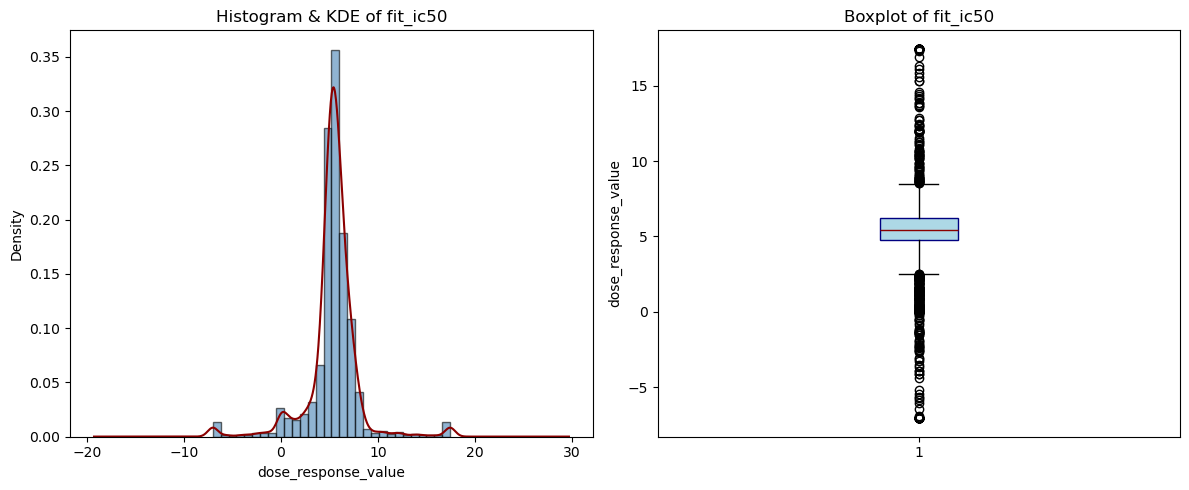

Dataset: mpnst
📊 Summary statistics for `fit_ic50`:

count    246.000000
mean       4.806167
std        6.063567
min      -29.523000
5%        -1.139650
25%        1.456250
50%        5.958000
75%        8.285500
95%       11.995000
max       12.000000



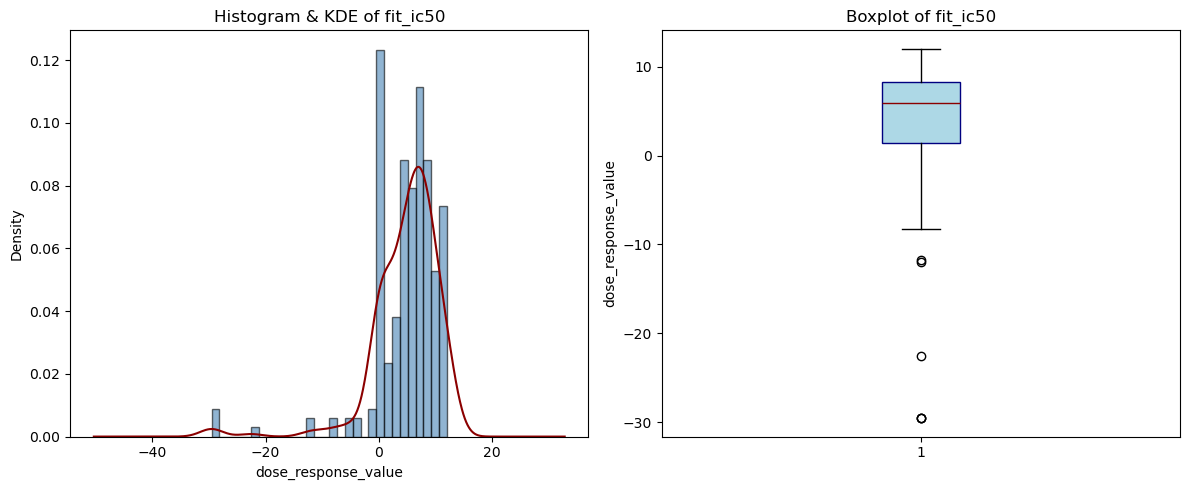

Dataset: nci60
📊 Summary statistics for `fit_ic50`:

count    2.104508e+06
mean     4.401531e+00
std      1.567485e+00
min     -2.171000e+00
5%       1.452000e+00
25%      3.850000e+00
50%      4.522000e+00
75%      5.253000e+00
95%      6.477000e+00
max      8.511000e+00



In [ ]:
for metric in avail_metrics:
    visualize_responses_across_datasets(loaded_datasets, metric=metric)

In [ ]:
data_attribute_check(loaded_datasets)

Dataset 'prism' has all required features ✅


In [ ]:
summary = summarize_datasets(loaded_datasets)

In [ ]:
for key, value in summary.items():
    print(f"{key}: ")
    for sub_key, sub_value in value.items():
        print(f"  {sub_key}: ")
        print(sub_value)

prism: 
  transcriptomics: 
                     dtype  num_null  pct_null  num_inf  num_unique  min  \
column                                                                     
entrez_id            int64         0       0.0        0       18866  1.0   
improve_sample_id    int64         0       0.0        0         473  1.0   
transcriptomics    float64         0       0.0        0      102860  0.0   
source              object         0       0.0        0           1  NaN   
study               object         0       0.0        0           1  NaN   

                           max  \
column                           
entrez_id          116033993.0   
improve_sample_id       1929.0   
transcriptomics        42572.0   
source                     NaN   
study                      NaN   

                                                      example_values  
column                                                                
entrez_id                             7105, 64102, 8813, 5

In [ ]:
include_copy_number = True
include_proteomics = True

to_remove = ["cptac", "hcmi"]
if (include_copy_number):
    new_to_remove = ["beataml", "sarcoma"]
    to_remove = list(set(to_remove + new_to_remove))

if (include_proteomics):
    new_to_remove = ["bladder", "colorectal", "novartis", "pancreatic", "sarcoma"]
    to_remove = list(set(to_remove + new_to_remove))

selected_datasets = {x: loaded_datasets[x] for x in datasets if x not in to_remove}

In [ ]:
# unify entries for each feature across datasets 
unified_datasets = {}
unified_datasets["transcriptomics"] = unify_feature_across_dataset(selected_datasets, feature="transcriptomics")
if include_proteomics:
    unified_datasets["proteomics"] = unify_feature_across_dataset(selected_datasets, feature="proteomics")
if include_copy_number:
    unified_datasets["copy_number"] = unify_feature_across_dataset(selected_datasets, feature="copy_number")
# for mutations, need to get total mutation variation types
all_mutation_types = get_total_mutation_types(selected_datasets)
for mut_type in all_mutation_types:
    unified_datasets[f"mutations_{mut_type}"] = unify_feature_across_dataset(selected_datasets, feature="mutations", mutation_type=mut_type)
unique_cell_ids_across_dfs = get_cell_id_across_dfs(unified_datasets)
print(f"Unified features {unified_datasets.keys()} across datasets.")

Unified features dict_keys(['transcriptomics', 'proteomics', 'copy_number', 'mutations_Nonsense_Mutation', 'mutations_In_Frame_Del', 'mutations_Splice_Site', 'mutations_Start_Codon_SNP', 'mutations_Silent', 'mutations_Start_Codon_Ins', 'mutations_Nonstop_Mutation', 'mutations_Missense_Mutation', 'mutations_In_Frame_Ins', 'mutations_Frame_Shift_Del', 'mutations_Frame_Shift_Ins']) across datasets.


In [ ]:
# Normalization
unified_datasets["transcriptomics"] = min_max_scaling_across_dfs(unified_datasets["transcriptomics"], "transcriptomics")
if include_proteomics:
    unified_datasets["proteomics"] = min_max_scaling_across_dfs(unified_datasets["proteomics"], "proteomics")
if include_copy_number:
    unified_datasets["copy_number"] = min_max_scaling_across_dfs(unified_datasets["copy_number"], "copy_number")

In [ ]:
summary2 = summarize_df_matrices(unified_datasets)

In [ ]:
print(summary2.keys())

dict_keys(['transcriptomics', 'proteomics', 'copy_number', 'mutations_Nonsense_Mutation', 'mutations_In_Frame_Del', 'mutations_Splice_Site', 'mutations_Start_Codon_SNP', 'mutations_Silent', 'mutations_Start_Codon_Ins', 'mutations_Nonstop_Mutation', 'mutations_Missense_Mutation', 'mutations_In_Frame_Ins', 'mutations_Frame_Shift_Del', 'mutations_Frame_Shift_Ins'])


In [ ]:
data_size_ref = {}
for data, value in unified_datasets["transcriptomics"].items():
    data_size_ref[data] = value.shape[0]
print(data_size_ref)

{'prism': 473}


In [ ]:
# Filter out biomarkers with too few samples
feature_reduced_dfs = filter_biomarkers(unified_datasets, data_size_ref, proportion=1e-2)

In [ ]:
dim_reduced_dfs = filter_feature(feature_reduced_dfs)

Feature transcriptomics: selected 1652 out of 18866 features
Feature proteomics: selected 57 out of 11454 features
Feature copy_number: selected 17 out of 18925 features
Feature mutations_Nonsense_Mutation: selected 379 out of 8212 features
Feature mutations_In_Frame_Del: selected 20 out of 1289 features
Feature mutations_Splice_Site: selected 474 out of 8145 features
Feature mutations_Start_Codon_SNP: selected 6 out of 511 features
Feature mutations_Silent: selected 8985 out of 17104 features
Feature mutations_Start_Codon_Ins: selected 9 out of 9 features
Feature mutations_Nonstop_Mutation: selected 12 out of 356 features
Feature mutations_Missense_Mutation: selected 14596 out of 18134 features
Feature mutations_In_Frame_Ins: selected 15 out of 296 features
Feature mutations_Frame_Shift_Del: selected 784 out of 8070 features
Feature mutations_Frame_Shift_Ins: selected 79 out of 4505 features


In [ ]:
drugs_ref_dfs = {}
for name, data in selected_datasets.items():
    drugs_ref_dfs[name] = data.drugs.drop_duplicates(subset=["improve_drug_id"], inplace=False)

experiments_dfs = {}
metric = "fit_auc"
for name, data in selected_datasets.items():
    experiments_dfs[name] = data.experiments[data.experiments["dose_response_metric"]==metric]

In [ ]:
experiments_dfs_sampled = dip_experiments_across_dfs(experiments_dfs, fraction=0.1)

In [ ]:
feature_dict_footprint, resp_footprint = preprocess_experiment_with_footprint(experiments_dfs_sampled, drugs_ref_dfs, dim_reduced_dfs, drug_target=None, show_status=True)

Processing dataset: prism with 63898 experiments
Finished processing dataset: prism with 63898 selected samples


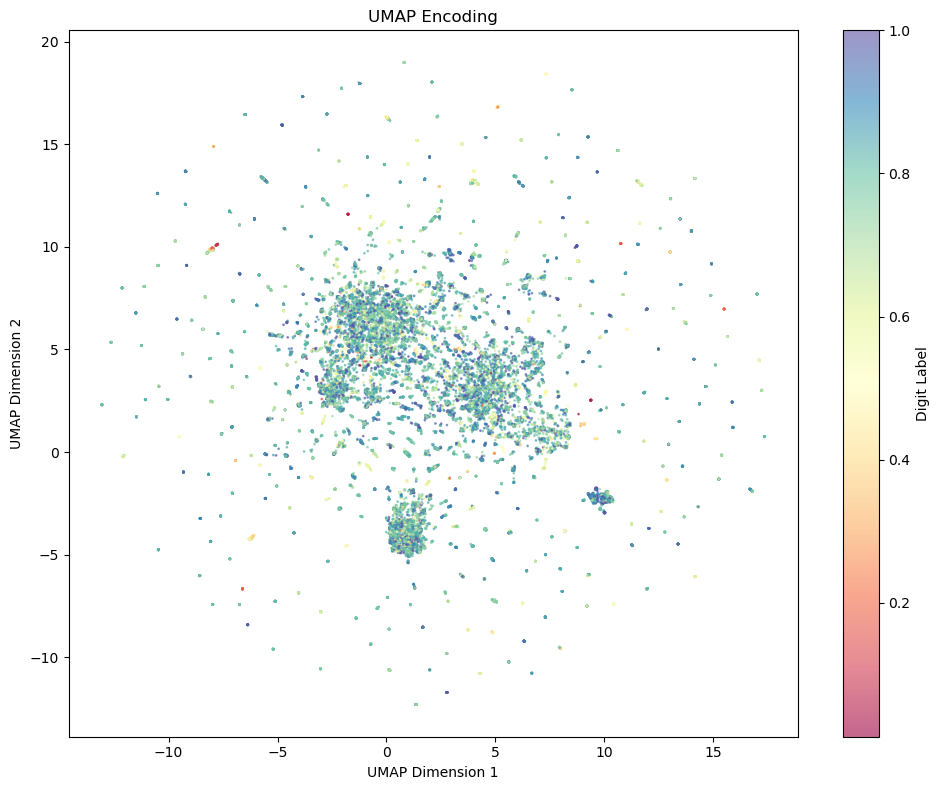

In [ ]:
# X, y = cat_drug_response_features_across_datasets(feature_dict_footprint, resp_footprint, unique_cell_ids_across_dfs, ["transcriptomics", "proteomics", "copy_number"])
X, y = cat_drug_response_features_across_datasets(feature_dict_footprint, resp_footprint, unique_cell_ids_across_dfs, ["transcriptomics", "proteomics", "copy_number"])

umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y, cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()